# Compress then explain: example with SHAP and CTE with predictions

Example of CTE(with predictions) using the [`shap` Python package](https://github.com/shap/shap) explaining a neural network trained on the `compas` dataset.

#### load packages

In [72]:
import numpy as np
from openxai.dataloader import ReturnLoaders
from openxai.model import LoadModel
from goodpoints import compress
import pandas as pd
import shap

load the dataset and model

In [73]:
_, loader_test = ReturnLoaders(data_name="compas", download=False, batch_size=128)
X_test = loader_test.dataset.data

model = LoadModel(data_name="compas", ml_model="ann", pretrained=True)
model.eval()

ArtificialNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)

create 2 new columns (target is binary)

In [74]:
predictions = model.predict(X_test)

In [75]:
X_test = np.concatenate((X_test, predictions), axis=1)
X_test

n = X_test.shape[0]
d = X_test.shape[1]
sigma = np.sqrt(2 * d) # sigma counted for a new number of features including the predictions

compress with target

In [76]:
id_cte = compress.compresspp_kt(X_test, kernel_type=b"gaussian", k_params=np.array([sigma**2]), g=4, seed=0)
X_cte = X_test[id_cte]

# delete 2 last columns
X_cte = np.delete(X_cte, -1, axis=1)
X_cte = np.delete(X_cte, -1, axis=1)

X_test = np.delete(X_test, -1, axis=1)
X_test = np.delete(X_test, -1, axis=1)

then explain

In [77]:
masker_cte = shap.maskers.Independent(X_cte, max_samples=X_cte.shape[0])
explainer_cte = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_cte, seed=0)
shap_cte = explainer_cte(X_test)

PermutationExplainer explainer: 1236it [00:10,  6.16it/s]                           


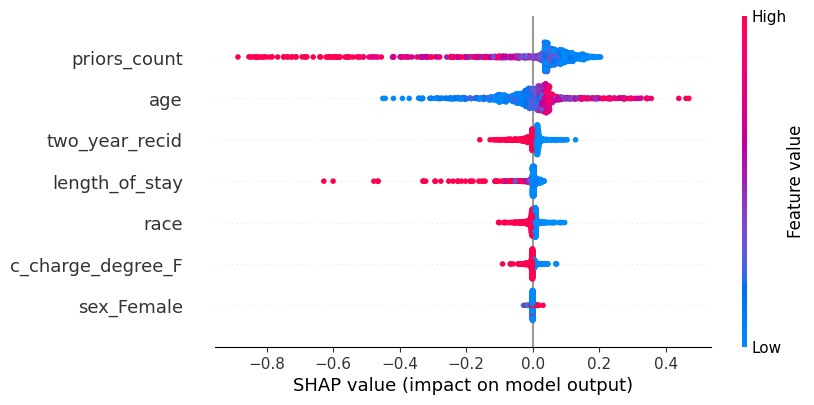

In [78]:
shap_cte.feature_names = loader_test.dataset.feature_names
shap.plots.beeswarm(shap_cte)

# compare with iid sampling

In [79]:
np.random.seed(0)
id_iid = np.random.choice(n, size=len(id_cte))
X_iid = X_test[id_iid]

In [80]:
masker_iid = shap.maskers.Independent(X_iid, max_samples=X_iid.shape[0])
explainer_iid = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_iid, seed=0)
shap_iid = explainer_iid(X_test)

PermutationExplainer explainer: 1236it [00:10,  7.06it/s]                           


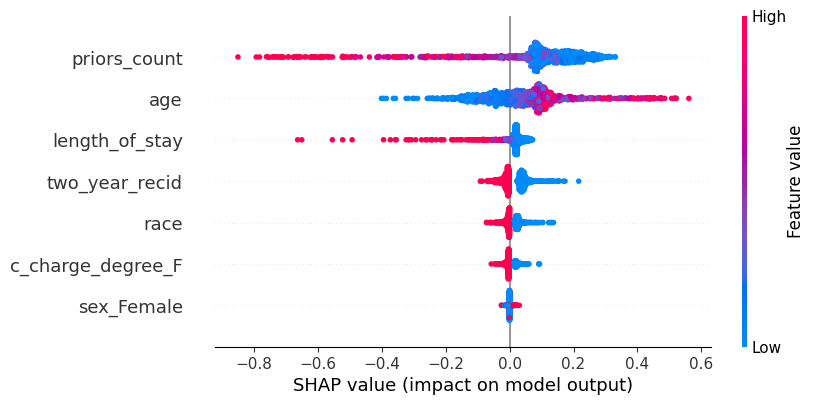

In [81]:
shap_iid.feature_names = loader_test.dataset.feature_names
shap.plots.beeswarm(shap_iid)

#### calculate "ground truth"

In [82]:
masker_gt = shap.maskers.Independent(X_test, max_samples=X_test.shape[0])
explainer_gt = shap.PermutationExplainer(lambda x: model.predict_proba(x)[:, 1], masker_gt, seed=0)
shap_gt = explainer_gt(X_test)

PermutationExplainer explainer: 1236it [03:19,  5.90it/s]                          


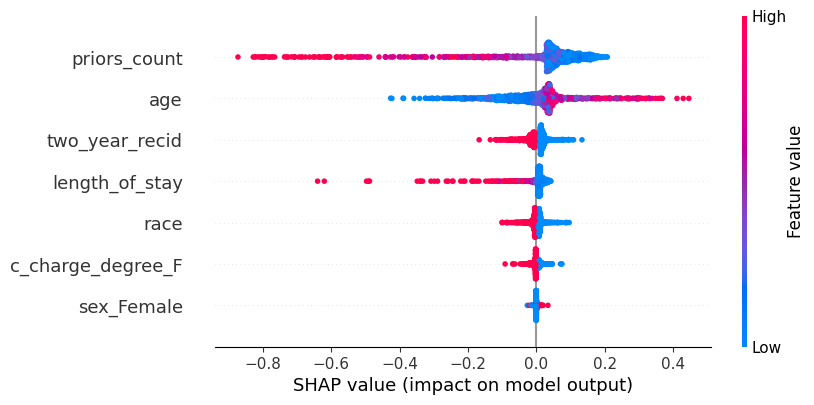

In [83]:
shap_gt.feature_names = loader_test.dataset.feature_names
shap.plots.beeswarm(shap_gt)

#### evaluate

In [84]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

In [85]:
print(f'Explanation approximation error introduced by CTE (compress with predictions):\
      {metric_mae(shap_gt.values, shap_cte.values):.4f}')
print(f'Explanation approximation error introduced by iid sampling:\
      {metric_mae(shap_gt.values, shap_iid.values):.4f}')
print(f'Relative improvement by CTE (compress with predictions):\
      {100*(metric_mae(shap_gt.values, shap_iid.values) - metric_mae(shap_gt.values, shap_cte.values)) / metric_mae(shap_gt.values, shap_iid.values):.2f}%')

Explanation approximation error introduced by CTE (compress with predictions):      0.0051
Explanation approximation error introduced by iid sampling:      0.0227
Relative improvement by CTE (compress with predictions):      77.73%


| Dataset name  | Model | Improvement (CTE with predictions) |
|-------|-------| ------ |
| heloc | ANN   | 61.88 % |
| compas| ANN   | 77.73 %|
| german| ANN   | 12.91 %|
| gaussian | ANN| 21.59 %|
| heart| ANN | 11.36 %|